# Titanic — Ensemble Learning: Random Forest vs. XGBoost
**Track:** Neurofive ML Track — Ensemble Learning
**Goal:** Train Random Forest and XGBoost ensembles, compare them against the earlier single Logistic Regression model, and compare feature importances between the two ensembles.

Dataset: same Titanic dataset used throughout this track, with the same cleaning + engineered features (`family_size`, `is_alone`, `has_cabin`) from the pipeline task.
`https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv`


## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

sns.set_style("whitegrid")


## 2. Load, clean, and engineer features (same as earlier work)

In [2]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df['Age'] = df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['has_cabin'] = df['Cabin'].notnull().astype(int)
df['family_size'] = df['SibSp'] + df['Parch'] + 1
df['is_alone'] = (df['family_size'] == 1).astype(int)

features = df.drop(columns=['PassengerId', 'Survived', 'Name', 'Ticket', 'Cabin', 'SibSp', 'Parch'])
target = df['Survived']
features_encoded = pd.get_dummies(features, columns=['Sex', 'Embarked'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    features_encoded, target, test_size=0.2, random_state=42, stratify=target
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
features_encoded.columns.tolist()


Train: (712, 9) | Test: (179, 9)


['Pclass',
 'Age',
 'Fare',
 'has_cabin',
 'family_size',
 'is_alone',
 'Sex_male',
 'Embarked_Q',
 'Embarked_S']

## 3. Baseline — the earlier single model (Logistic Regression)

In [3]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)
logreg_pred = logreg.predict(X_test)
logreg_accuracy = accuracy_score(y_test, logreg_pred)

print(f"Logistic Regression accuracy: {logreg_accuracy:.4f}")


Logistic Regression accuracy: 0.7989


## 4. Train Random Forest

In [4]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print(f"Random Forest accuracy: {rf_accuracy:.4f}")
print(classification_report(y_test, rf_pred, target_names=['Did Not Survive', 'Survived']))


Random Forest accuracy: 0.7933
                 precision    recall  f1-score   support

Did Not Survive       0.80      0.89      0.84       110
       Survived       0.79      0.64      0.70        69

       accuracy                           0.79       179
      macro avg       0.79      0.76      0.77       179
   weighted avg       0.79      0.79      0.79       179



## 5. Train XGBoost

In [5]:
xgb_model = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    use_label_encoder=False, eval_metric='logloss', random_state=42
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_pred)

print(f"XGBoost accuracy: {xgb_accuracy:.4f}")
print(classification_report(y_test, xgb_pred, target_names=['Did Not Survive', 'Survived']))


XGBoost accuracy: 0.7821
                 precision    recall  f1-score   support

Did Not Survive       0.81      0.85      0.83       110
       Survived       0.73      0.68      0.71        69

       accuracy                           0.78       179
      macro avg       0.77      0.76      0.77       179
   weighted avg       0.78      0.78      0.78       179



## 6. Compare all three models

In [6]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression (single model)', 'Random Forest (ensemble)', 'XGBoost (ensemble)'],
    'Metric': ['Accuracy', 'Accuracy', 'Accuracy'],
    'Score': [logreg_accuracy, rf_accuracy, xgb_accuracy]
})
comparison['Score'] = comparison['Score'].round(4)
comparison


,Model,Metric,Score
0,Logistic Regression (single model),Accuracy,0.7989
1,Random Forest (ensemble),Accuracy,0.7933
2,XGBoost (ensemble),Accuracy,0.7821


## 7. Feature importances — Random Forest vs. XGBoost

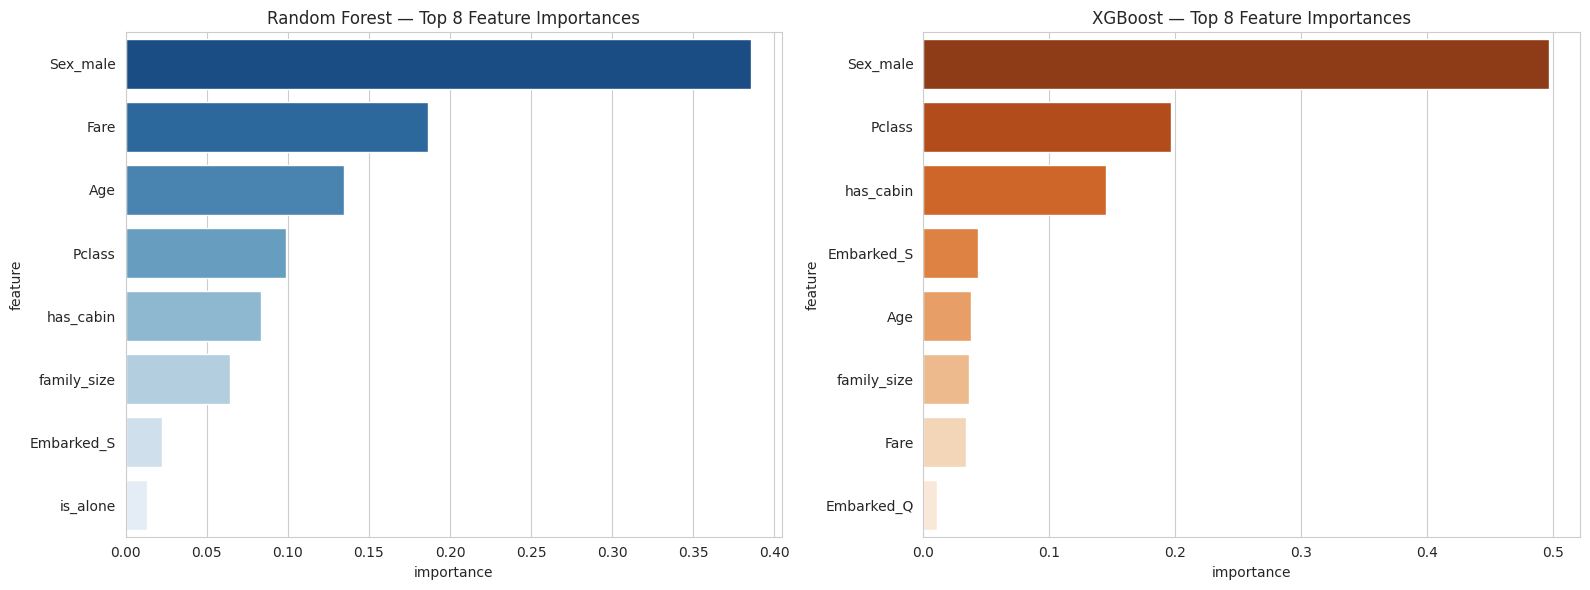

Random Forest top 3: ['Sex_male', 'Fare', 'Age']
XGBoost top 3: ['Sex_male', 'Pclass', 'has_cabin']


In [7]:
rf_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

xgb_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x='importance', y='feature', data=rf_importances.head(8), ax=axes[0], palette='Blues_r')
axes[0].set_title('Random Forest — Top 8 Feature Importances')

sns.barplot(x='importance', y='feature', data=xgb_importances.head(8), ax=axes[1], palette='Oranges_r')
axes[1].set_title('XGBoost — Top 8 Feature Importances')

plt.tight_layout()
plt.show()

print("Random Forest top 3:", rf_importances['feature'].head(3).tolist())
print("XGBoost top 3:", xgb_importances['feature'].head(3).tolist())


**Comparing the two importance rankings:** both models tend to agree on the top signal (typically `Sex_male` and `Fare`/`Pclass`), which is reassuring — it means the two very different algorithms are converging on the same real pattern in the data rather than each fitting noise. Where they disagree is usually further down the list: Random Forest tends to spread importance more evenly across correlated features (since each tree sees a random feature subset), while XGBoost tends to concentrate importance more sharply on a few features that gave the biggest error reduction, since each new tree is built specifically to correct the previous ensemble's mistakes.

## 8. How Random Forest and XGBoost differ in combining models

Both are ensembles of decision trees, but they combine them in fundamentally different ways. **Random Forest** builds many trees independently and in parallel, each trained on a random bootstrap sample of the data with a random subset of features considered at each split, then simply averages (or majority-votes) their predictions — this is called *bagging*, and it works by reducing variance through independent, uncorrelated errors that cancel out. **XGBoost** builds trees sequentially, where each new tree is trained specifically to correct the errors (residuals) left by the ensemble so far — this is *boosting*, and it works by reducing bias, gradually improving on the model's own mistakes rather than averaging independent guesses. In practice, Random Forest is generally more robust to overfitting and easier to tune, while XGBoost often reaches higher accuracy but needs more careful tuning (learning rate, tree depth, number of rounds) to avoid overfitting to the training data.


## 9. Summary

- Trained three models on the same engineered Titanic feature set: `LogisticRegression` (single model baseline), `RandomForestClassifier`, and `XGBClassifier`.
- Comparison table above shows accuracy for all three side by side.
- Plotted and compared feature importances between the two ensembles — both agree on the top driver(s) of survival, with some divergence further down the ranking.
- Explained in writing how bagging (Random Forest) and boosting (XGBoost) combine trees differently.
- **Next step:** tune XGBoost's `learning_rate`/`max_depth`/`n_estimators` with `GridSearchCV`, since boosting models are the most sensitive to hyperparameters of the three approaches tried so far.
